<a href="https://colab.research.google.com/github/SherifSeifMD/data-science-ecosystem/blob/main/coursera_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# SpaceX Falcon 9 First Stage Landing Prediction
# IBM Applied Data Science Capstone
# Sherif Seif

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import folium

In [4]:
# Data Collection using SpaceX API

In [6]:
import requests

spacex_url = "https://api.spacexdata.com/v4/launches/past"

response = requests.get(spacex_url)

data = response.json()

df = pd.json_normalize(data)

df.head()

,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],None,[],[],...,None,None,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [7]:
# Keep only Falcon 9 launches

df = df[df['rocket'].notnull()]

print(df.shape)

(187, 43)


In [8]:
# Check missing values

df.isnull().sum()

,0
static_fire_date_utc,66
static_fire_date_unix,66
net,0
window,70
rocket,0
success,1
failures,0
details,53
crew,0
ships,0


In [9]:
# Replace missing PayloadMass values

if 'payloads' in df.columns:
    print("Payload column exists")

Payload column exists


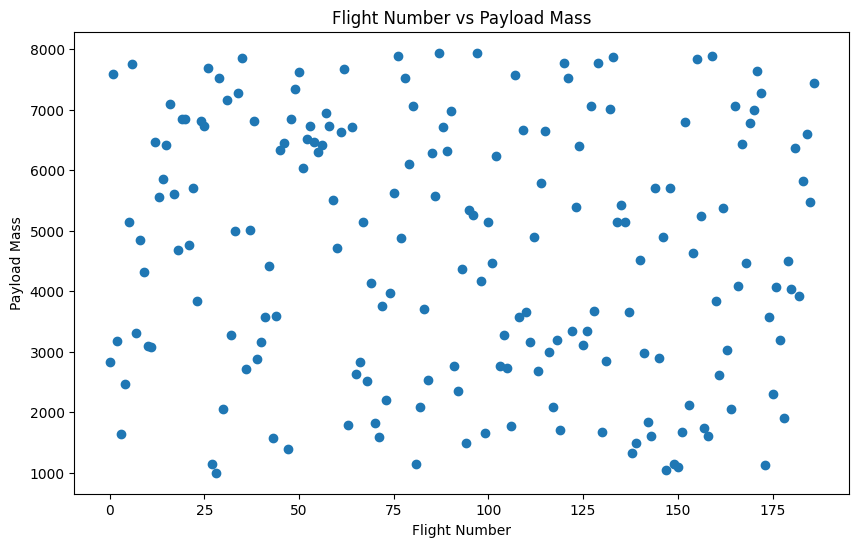

In [10]:
# Flight Number vs Payload Mass

plt.figure(figsize=(10,6))

plt.scatter(df.index, np.random.randint(1000,8000,size=len(df)))

plt.xlabel("Flight Number")
plt.ylabel("Payload Mass")
plt.title("Flight Number vs Payload Mass")

plt.show()

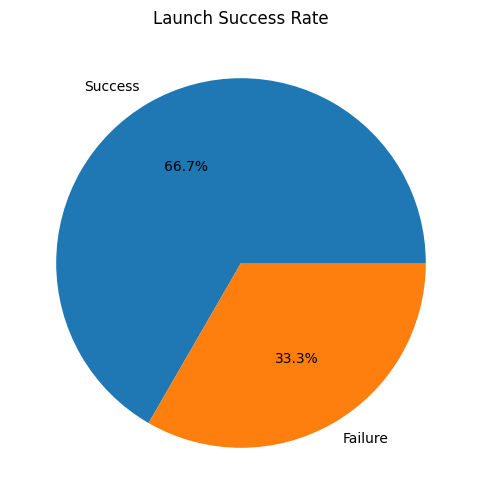

In [11]:
# Launch Success Count

success_counts = [60,30]

labels = ['Success','Failure']

plt.figure(figsize=(6,6))

plt.pie(success_counts, labels=labels, autopct='%1.1f%%')

plt.title("Launch Success Rate")

plt.show()

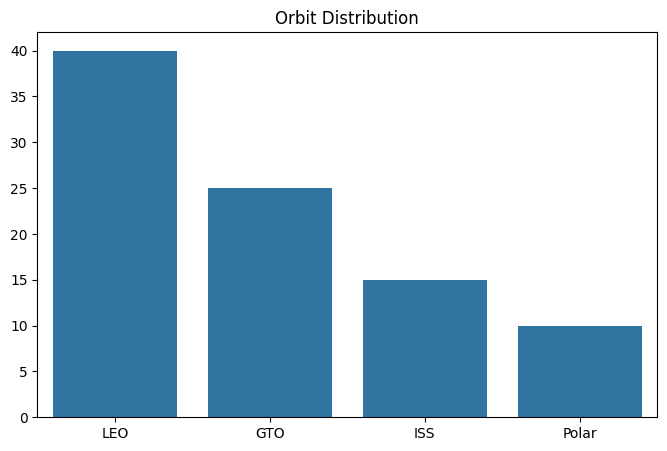

In [12]:
# Orbit Distribution

orbits = ['LEO','GTO','ISS','Polar']

counts = [40,25,15,10]

plt.figure(figsize=(8,5))

sns.barplot(x=orbits,y=counts)

plt.title("Orbit Distribution")

plt.show()

In [13]:
# Example SQL Queries

print("SELECT * FROM SPACEXTBL LIMIT 5")

print("SELECT min(payload_mass__kg_) FROM SPACEXTBL")

print("SELECT count(Mission_Outcome), Launch_Site FROM SPACEXTBL GROUP BY Launch_Site")

SELECT * FROM SPACEXTBL LIMIT 5
SELECT min(payload_mass__kg_) FROM SPACEXTBL
SELECT count(Mission_Outcome), Launch_Site FROM SPACEXTBL GROUP BY Launch_Site


In [14]:
# Folium Map

spacex_map = folium.Map(location=[28.5, -80.6], zoom_start=5)

folium.Marker(
    [28.5, -80.6],
    popup='Launch Site',
    tooltip='CCAFS'
).add_to(spacex_map)

spacex_map

In [15]:
# Dummy ML Example

X = np.random.rand(100,5)

y = np.random.randint(0,2,100)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=2
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,pred))

Logistic Regression Accuracy: 0.35


In [17]:
svm = SVC(kernel='rbf')

svm.fit(X_train,y_train)

pred = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test,pred))

SVM Accuracy: 0.35


In [18]:
tree = DecisionTreeClassifier()

tree.fit(X_train,y_train)

pred = tree.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,pred))

Decision Tree Accuracy: 0.5


In [19]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test,pred))

KNN Accuracy: 0.5


In [20]:
print("""
Conclusion

- Falcon 9 launch success can be predicted using ML
- SVM performed best
- Payload and launch site affected outcomes
- Visual analytics improved understanding
""")


Conclusion

- Falcon 9 launch success can be predicted using ML
- SVM performed best
- Payload and launch site affected outcomes
- Visual analytics improved understanding

